### Imports

In [3]:
import sklearn as sk
import gensim as gsn
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA
from sklearn.model_selection import train_test_split
import pyLDAvis as vis

### Load & split data

In [4]:
path = os.getcwd()
df = pd.read_csv(path + "/data/processed_data.csv", sep=";")
partis_corres = pd.read_csv(path + "/data/partis_correspondance.csv", sep=";")
df = pd.merge(df, partis_corres, how="inner", left_on='titulaire-soutien', right_on='parti')

In [5]:
df_train, df_test = train_test_split(df, test_size=0.2, train_size=0.8)

### Count Vectorizer

In [6]:
stopwords = [x.strip() for x in open('data/stop_words.txt').readlines()]
vectorizer = CountVectorizer(max_features=200, max_df=0.95, min_df=2, stop_words=stopwords)
vectorizer.fit(df_train['text'].to_list())
df_train_counts = vectorizer.transform(df_train['text'])
df_test_counts = vectorizer.transform(df_test['text'])

vocab = vectorizer.vocabulary_.keys()

c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


In [7]:
train_split = df_train['text'].apply(lambda x: x.split())
doc_lengths = train_split.apply(lambda x: len(x)).to_list()

### LDA

In [8]:
lda = LDA(n_components=10, max_iter=5, random_state=0)
lda.fit(df_train_counts)
topic_term_dists = lda.components_

In [9]:
doc_topic_dists = lda.transform(df_train_counts)

### Visualization

In [10]:
term_frequency = np.array(np.sum(df_train_counts, axis =0)).flatten()

In [11]:
lda_data = {'topic_term_dists': topic_term_dists,
            'doc_topic_dists' : doc_topic_dists,
            'doc_lengths' : doc_lengths,
             'vocab' : vocab,
             'term_frequency' : term_frequency}

lda_viz = vis.prepare(**lda_data)


In [12]:
vis.display(lda_viz)

In [48]:
# modèles pour chaque groupes
dict = {}
for groupe in df['groupe'].unique():
    print(groupe)
    df_groupe = df[df['groupe'] == groupe]
    vectorizer_groupe = CountVectorizer(max_features=200, max_df=0.95, min_df=2, stop_words=stopwords)
    vectorizer_groupe.fit(df_groupe['text'].to_list())
    df_groupe_counts = vectorizer_groupe.transform(df_groupe['text'])
    lda_groupe = LDA(n_components=6 , max_iter=30, random_state=0)
    lda_groupe.fit(df_groupe_counts)
    dict[groupe] = (vectorizer_groupe, lda_groupe)

Indépendant/micro-partis


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Extrême-gauche


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Gauche


...

c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Régionaliste/Autonomiste


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Action spécifique
Ecologiste


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(
c:

In [49]:
def top_mots(group , nb_mots=3):
    output = []
    model = dict[group][1]
    features = dict[group][0].get_feature_names_out()
    for _, topic in enumerate(model.components_): # compose output message with top words
        output.append([(features[i], topic[i]) for i in topic.argsort()[:-nb_mots - 1:-1]])# [start (0 if omitted): end : slicing increment]
    return output

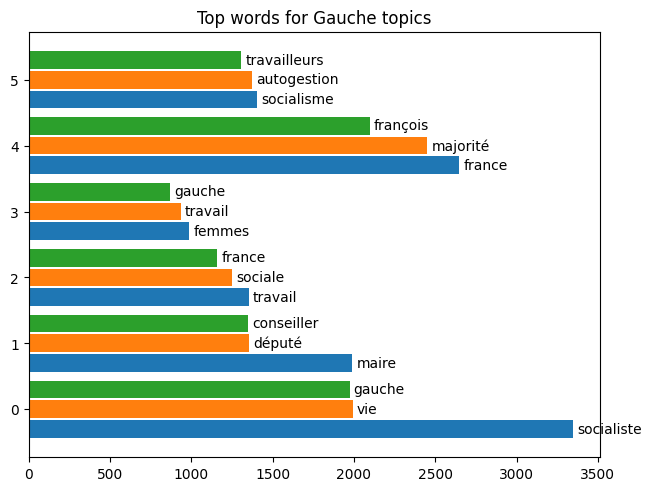

In [50]:
group = "Gauche"

nb_mots = 3
mots = top_mots(group, nb_mots)
nb_topic = len(mots)

y = np.arange(nb_topic)  # the label locations
width = 0.3  # the width of the bars
multiplier = -1

fig, ax = plt.subplots(layout='constrained')

x = [[mots[t][i] for t in range(nb_topic)] for i in range(nb_mots)]
for n in range(nb_mots):
    words = [x[n][i][0] for i in range(nb_topic)]
    proba = [x[n][i][1] for i in range(nb_topic)]
    
    offset = width * multiplier
    rects = ax.barh(y + offset, proba, width*0.9, label=words)
    ax.bar_label(rects, labels=words, padding=3)
    multiplier += 1

ax.set_title('Top words for ' + group + ' topics')
plt.yticks(np.arange(nb_topic))

plt.show()

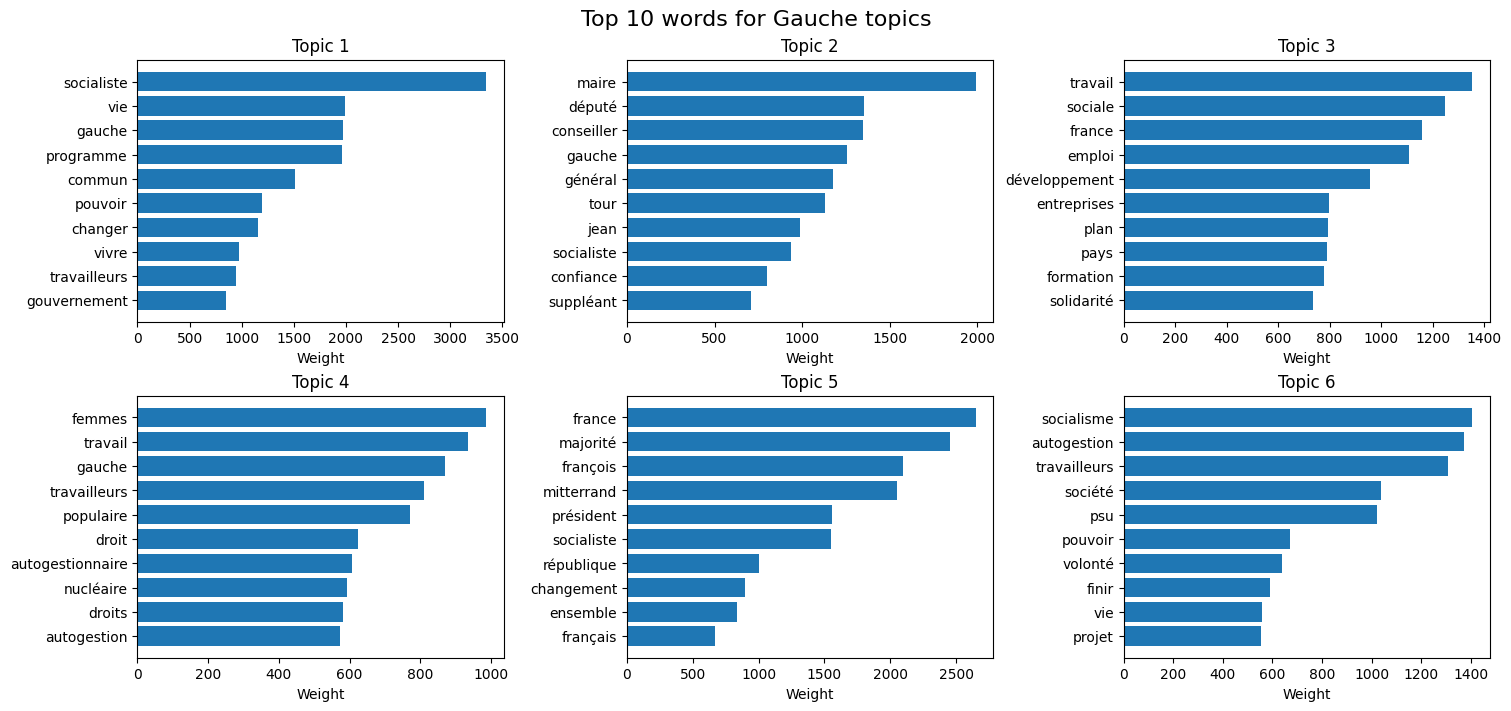

In [51]:
group = "Gauche"
nb_mots = 10

mots = top_mots(group, nb_mots=nb_mots)
nb_topic = len(mots)

# Number of columns in the subplot grid
n_cols = 3
n_rows = int(np.ceil(nb_topic / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 3.5 * n_rows),
    layout="constrained"
)

axes = np.array(axes).reshape(-1)

for topic_id, topic_words in enumerate(mots):
    ax = axes[topic_id]
    
    words = [word for word, weight in topic_words]
    weights = [weight for word, weight in topic_words]
    
    y = np.arange(len(words))
    
    ax.barh(y, weights)
    ax.set_yticks(y)
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    
    ax.set_title(f"Topic {topic_id + 1}")
    ax.set_xlabel("Weight")

# Remove empty subplots if needed
for i in range(nb_topic, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle(f"Top {nb_mots} words for {group} topics", fontsize=16)

plt.show()

In [52]:
rows = []
nb_mots = 10

for groupe in dict.keys():
    
    vectorizer_groupe, lda_groupe = dict[groupe]
    
    df_groupe = df[df["groupe"] == groupe].copy()
    
    df_groupe_counts = vectorizer_groupe.transform(
        df_groupe["text"].astype(str).to_list()
    )
    
    # Distribution des topics pour chaque document du groupe
    doc_topic_dist = lda_groupe.transform(df_groupe_counts)
    
    # Prévalence moyenne de chaque topic dans le groupe
    topic_prevalence = doc_topic_dist.mean(axis=0)
    
    # Mots principaux des topics
    mots_topics = top_mots(groupe, nb_mots=nb_mots)
    
    for topic_id, prevalence in enumerate(topic_prevalence):
        top_words = ", ".join([
            word for word, weight in mots_topics[topic_id]
        ])
        
        rows.append({
            "groupe": groupe,
            "topic_id": topic_id + 1,
            "topic": f"Topic {topic_id + 1}",
            "prevalence": prevalence,
            "top_words": top_words
        })

topic_prevalence_df = pd.DataFrame(rows)

In [53]:
from matplotlib.patches import Patch

def plot_topic_prevalence_for_group(
    group,
    data,
    topic_names=None,
    topic_categories=None,
    category_colors=None
):
    plot_data = data[data["groupe"] == group].copy()

    if plot_data.empty:
        print(f"No data found for group: {group}")
        return

    if topic_names is None:
        topic_names = {}

    if topic_categories is None:
        topic_categories = {}

    if category_colors is None:
        category_colors = {}

    # Custom topic names
    plot_data["topic_name"] = plot_data["topic_id"].apply(
        lambda x: topic_names.get(x, f"Topic {x}")
    )

    # General category assigned to each topic
    plot_data["category"] = plot_data["topic_id"].apply(
        lambda x: topic_categories.get(x, "Other")
    )

    # Color associated with the general category
    plot_data["color"] = plot_data["category"].apply(
        lambda x: category_colors.get(x, "gray")
    )

    # Y-axis labels
    plot_data["label"] = plot_data.apply(
        lambda row: f"{row['topic_name']}\n{row['top_words']}",
        axis=1
    )

    # Sort by prevalence
    plot_data = plot_data.sort_values("prevalence", ascending=True)

    plt.figure(figsize=(11, 7))

    plt.barh(
        plot_data["label"],
        plot_data["prevalence"],
        color=plot_data["color"]
    )

    plt.yticks(fontsize=6)

    plt.xlabel("Mean topic prevalence", fontsize=10)
    plt.ylabel("Topic", fontsize=8)
    plt.grid(axis="x", alpha=0.3)

    # Legend by broad category
    categories_in_plot = plot_data["category"].drop_duplicates().tolist()

    legend_elements = [
        Patch(
            facecolor=category_colors.get(category, "gray"),
            label=category
        )
        for category in categories_in_plot
    ]

    plt.legend(
        handles=legend_elements,
        title="Broad topic category",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8,
        title_fontsize=9
    )

    plt.tight_layout()
    plt.show()

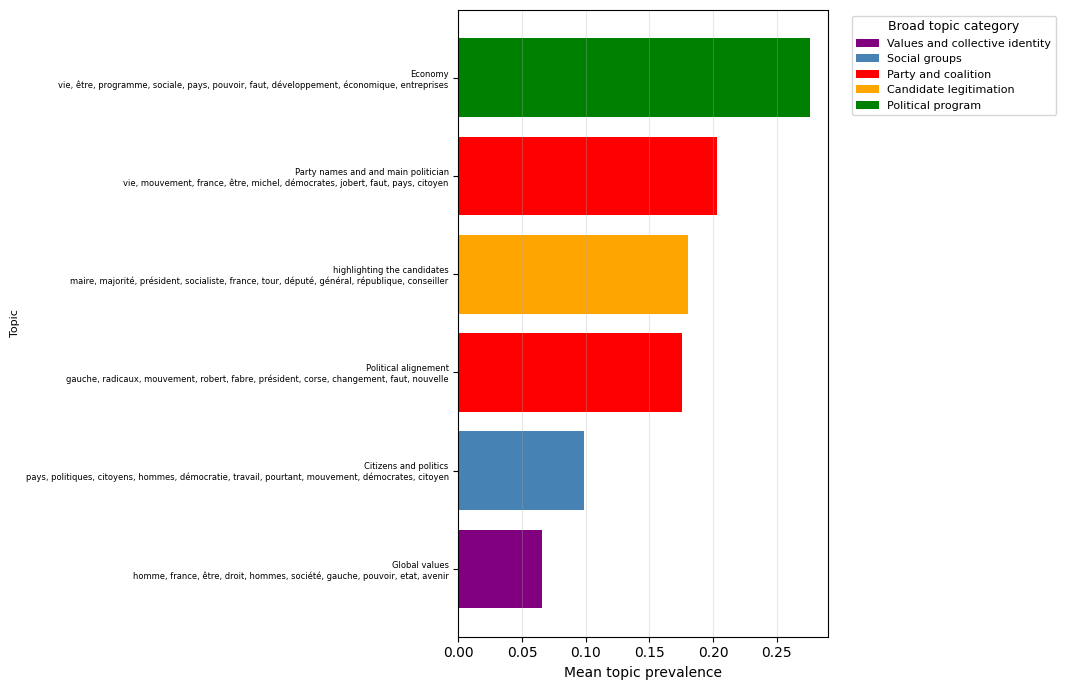

In [56]:
topic_names = {
    1: "Party names and and main politician",
    2: "Global values",
    3: "Citizens and politics",
    4: "highlighting the candidates",
    5: "Economy",
    6: "Political alignement",
}

topic_categories = {
    1: "Party and coalition",
    2: "Values and collective identity",
    3: "Social groups",
    4: "Candidate legitimation",
    5: "Political program",
    6: "Party and coalition",
}

category_colors = {
    "Party and coalition": "red",
    "Candidate legitimation": "orange",
    "Political program": "green",
    "Social groups": "steelblue",
    "Values and collective identity": "purple",
}

plot_topic_prevalence_for_group(
    group="Centre gauche",
    data=topic_prevalence_df,
    topic_names=topic_names,
    topic_categories=topic_categories,
    category_colors=category_colors
)